In [5]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

**See first:** [Conditioning](../1_intro/3_conditioning.ipynb)

## Gauss-Markov model

We consider the linear dynamical system (without an input)
$$\begin{align}
    x_{t+1} {}={} & A_t x_t + G_t w_t,
    \\
    y_t {}={}     & C_t x_t + v_t,
  \end{align}$$
where $x_t\in{\rm I\!R}^{n_x}$ is the system state, $y_t\in{\rm I\!R}^{n_y}$ is the *output*, $w_t\in{\rm I\!R}^{n_w}$ is a noise term acting on the system dynamics known as *process noise*, and $v_t\in{\rm I\!R}^{n_v}$ is a measurement noise term.

Moreover, $A_t$, $G_t$, and $C_t$, are matrices of appropriate dimensions (sometimes, they are constant in time). Let us make some simplifying assumptions for this system.

**Assumptions:** (i) ${\rm I\!E}[w_t]=0$ and ${\rm I\!E}[v_t]=0$ for all $t\in{\rm I\!N}$, (ii) $x_0$, $(w_t)_t$ and $(v_t)_t$ are mutually independent random variables, (iii) $w_t$ and $v_t$ are normally distributed and ${\rm I\!E}[w_tw_t^\intercal]=Q_t$, ${\rm I\!E}[v_tv_t^\intercal]=R_t$. Lastly, $x_0$ is a random variable and (iv) $x_0 \sim \mathcal{N}(\tilde{x}_0, P_0)$. $\Box$

In [6]:
# This is a useful function: it plots contours of the pdf of the 2D normal distribution
def plot_2d_normal_pdf(mu, cov, alpha=1):
    """
    Plots contours of 2D normal pdf

    :param mu: expected value
    :param cov: covariance matrix (2-by-2)
    :param alpha: transparency (alpha=1 is no transparency)
    """
    dx1 = 3.5 * np.sqrt(cov[0, 0])
    dx2 = 3.5 * np.sqrt(cov[1, 1])
    x, y = np.mgrid[mu[0]-dx1:mu[0]+dx1:.05, mu[1]-dx2:mu[1]+dx2:.05]
    pos = np.dstack((x, y))
    z = stats.multivariate_normal.pdf(pos, mu, cov)
    plt.contour(x, y, z, levels=10, alpha=alpha)

## Evolution of states

Define $\tilde{x}_t = {\rm I\!E}[x_t]$; then,
$$\begin{align}
  \tilde{x}_{t+1} {}={} & {\rm I\!E}[x_{t+1}] = {\rm I\!E}[A_tx_{t} + G_tw_t]
  {}={} A_t {\rm I\!E}[x_t]
  {}={} A_t \tilde{x}_t.
\end{align}$$
Define $P_{t} = {\rm Var}[x_t]$. Then,
$$P_{t+1} {}={\rm Var}[A_t x_t + G_t w_t] = {\rm Var}[A_i x_t] + {\rm Var}[G_t w_t] = A_t P_t A_t^\intercal + G_t{}Q_t{}G_t^\intercal.$$

We have
$$P_{t+1} = AP_t A^\intercal + Q.$$
What if $A=I$; then
$$P_{t+1} = P_t + Q.$$
At $t=0$ we have $P_0$, at time $t=1$ we have $P_1 = P_0 + Q$, at time $t=2$ we have $P_2 = P_1 + Q = P_0 + 2Q$. And in general, at time $t$ we have
$$P_{t} = P_0 + t Q.$$

### Example 1

Consider the system
$$x_{t+1} = \begin{bmatrix}\phantom{-}0.5& 0.3\\ -0.2& 0.5\end{bmatrix}x_t + w_t,$$
where the process noise satisfies
$$w_t \sim \mathcal{N}\left(0, \begin{bmatrix}0.10& 0.05\\ 0.05& 0.15\end{bmatrix}\right),$$
and the initial condition
$$x_0\sim\mathcal{N}\left(\begin{bmatrix}\phantom{-}5\\ -1\end{bmatrix}, \begin{bmatrix}0.9 & 0.4\\0.4& 0.3\end{bmatrix}\right).$$

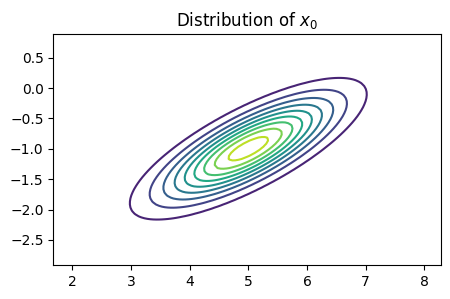

In [7]:
Q = np.array([[0.1, 0.05],
              [0.05, 0.15]])
P0 = np.array([[0.9, 0.4],
               [0.4, 0.3]])
x0_tilde = np.array([5, -1])
plt.figure(figsize=(5, 3))
plot_2d_normal_pdf(x0_tilde, P0)
plt.title('Distribution of $x_0$')
plt.show()

We know that $\tilde{x}_1=A\tilde{x}_0$ and $P_1 = AP_0A^\intercal + Q$, and
$$x_1 \sim \mathcal{N}(\tilde{x}_1, P_1).$$
Let us compute $\tilde{x}_1$ and $P_1$ and then let's plot the pdf of $x_1$.

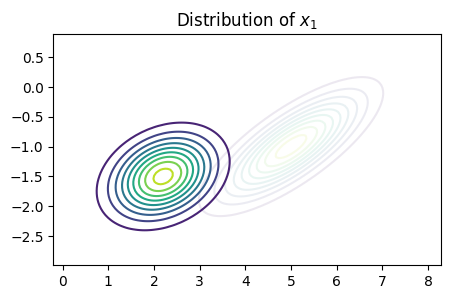

In [4]:
A = np.array([[0.5, 0.3],
              [-0.2, 0.5]])
x1_tilde = A @ x0_tilde
P1 = A @ P0 @ A.T + Q
plt.figure(figsize=(5, 3))
plot_2d_normal_pdf(x0_tilde, P0, alpha=0.1)
plt.title('Distribution of $x_1$')
plot_2d_normal_pdf(x1_tilde, P1)
plt.show()

**Exercise:** Plot the distribution of $x_2$.

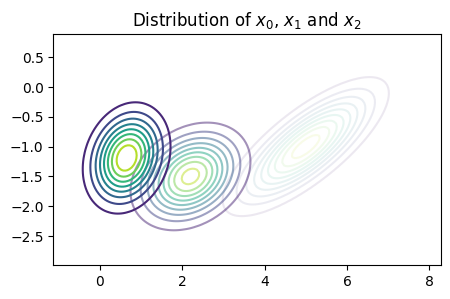

In [5]:
# Your code goes here
x2_tilde = A @ x1_tilde
P2 = A @ P1 @ A.T + Q
plt.figure(figsize=(5, 3))
plot_2d_normal_pdf(x0_tilde, P0, alpha=0.1)
plt.title('Distribution of $x_0$, $x_1$ and $x_2$')
plot_2d_normal_pdf(x1_tilde, P1, alpha=0.5)
plot_2d_normal_pdf(x2_tilde, P2)
plt.show()

**Exercise:** Using a `for` loop, plot the distributions of $x_0,\ldots, x_{10}$.

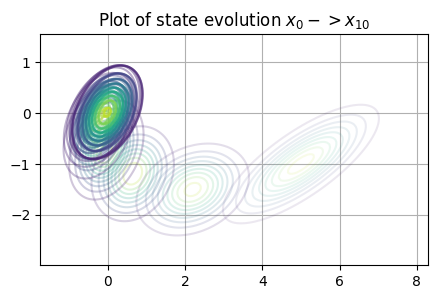

In [6]:
plt.figure(figsize=(5, 3))
x_tilde = x0_tilde
P = P0

for i in range(11):
    plot_2d_normal_pdf(x_tilde, P, alpha=0.10 + i*0.05)
    x_tilde = A @ x_tilde
    P = A @ P @ A.T + Q

plt.title('Plot of state evolution $x_0 -> x_{10}$')
plt.grid()

## Outputs

For the output we have $y_t = C_tx_t + v_t$, so
$${\rm I\!E}[y_t] = C_t{\rm I\!E}[x_t] = C_t\tilde{x}_t,$$
and
$${\rm Var}[y_t] = {\rm Var}[C_tx_t + v_t] = C_t P_t C_t^\intercal + R_t.$$
We, therefore, have that $y_t \sim \mathcal{N}(C_t\tilde{x}_t, C_t P_t C_t^\intercal + R_t)$.
Moreover,
$${\rm Cov}(x_t, y_t)={\rm Cov}(x_t, C_t x_t + v_t)=
{\rm Cov}(x_t, C_t x_t)  +{\rm Cov}(x_t, v_t)= P_t C_t.$$
**Question:** What is the distribution of $(x_t, y_t)$?

Answer: Likely Gaussian

### Example 2

Consider the same dynamical system as in Example 1 and let $C=[1 ~~ 0]$. Suppose also that $R=0.7$. We can then determine the distribution of $y_0$ as follows



In [28]:
# Problem data
C = np.array([
    [1, 0]
])
R = 0.7
# Expectation and variance of y0
y0_expect = C @ x0_tilde
y0_var = C @ P0 @ C.T + R
print(f"E[y0] = {y0_expect[0]}")
print(f"Var[y0] = {y0_var[0][0]}")

# Let's determine E[y1] and Var[y1]
x1_tilde = A @ x0_tilde
P1 = A @ P0 @ A.T + Q
y1_expect = C @ x1_tilde
y1_var = C @ P1 @ C.T + R
print(f"E[y1] = {y1_expect[0]}")
print(f"Var[y1] = {y1_var[0][0]}")

E[y0] = 5
Var[y0] = 1.6
E[y1] = 2.2
Var[y1] = 1.172


**Exercise:** Using a `for` loop, determine the mean and variance of $y_0, \ldots, y_{10}$.

In [8]:
x_tilde = x0_tilde
P = P0

for i in range(50):
    y_expect = C @ x_tilde
    y_var = C @ P @ C.T + R

    x_tilde = A @ x_tilde
    P_new = A @ P @ A.T + Q

    print(np.linalg.norm(P_new - P, np.inf))
    P = P_new


0.7470000000000001
0.24906999999999996
0.0796319
0.02017250499999998
0.005827373399999988
0.001497707733299991
0.0005571070535279887
0.00021245812711116752
6.694227769958594e-05
2.20105314128749e-05
5.247094284427378e-06
1.58532324213978e-06
4.324103077268937e-07
1.5106337861170438e-07
6.00465438621578e-08
1.788155142012915e-08
6.049461431789638e-09
1.3535313425627749e-09
4.2860934246213844e-10
1.2389909931354026e-10
4.0704536963254156e-11
1.686821515800574e-11
4.745925874516388e-12
1.6532469837571284e-12
3.606559495494821e-13
1.1515788322924436e-13
3.524958103184872e-14
1.0894063429134349e-14
4.704570066849101e-15
1.2906342661267445e-15
4.579669976578771e-16
1.1102230246251565e-16
2.7755575615628914e-17
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


**Exercise:** Verify that the sequence of variances, $(P_t)_t$, converges to a variance, $P$. Verify also that $P$ satisfies the equation $P = APA^\intercal + Q$ (known as the Lyapunov equation). This result is not valid for all matrices $A$. Can you find a counterexample?

In [9]:
P - (A @ P @ A.T + Q)

array([[0., 0.],
       [0., 0.]])

**See next:** [Kalman filter](./2_kalman_basic.ipynb)